<a href="https://colab.research.google.com/github/Karuneshtiwari/ML-lab/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics.pairwise import cosine_similarity

In [11]:
from google.colab import drive
drive.mount('/content/drive')

DATA_FILE = "/content/drive/MyDrive/ML_lab/Lab Session Data.xlsx"

Mounted at /content/drive


In [12]:
def load_excel_file(file_path):
    return pd.ExcelFile(file_path)


def load_sheet(file_path, sheet_name):
    return pd.read_excel(file_path, sheet_name=sheet_name)

In [13]:
def prepare_feature_output_matrix(dataframe):
    """
    Creates Feature Matrix X and Output Vector y.

    Returns:
        X : Feature Matrix
        y : Output Vector
    """

    X = dataframe[
        ['Candies (#)',
         'Mangoes (Kg)',
         'Milk Packets (#)']
    ].values

    y = dataframe['Payment (Rs)'].values

    return X, y


def calculate_vector_dimension(feature_matrix):
    """
    Returns dimensionality of feature space.
    """
    return feature_matrix.shape[1]


def calculate_number_of_vectors(feature_matrix):
    """
    Returns number of observation vectors.
    """
    return feature_matrix.shape[0]


def calculate_matrix_rank(feature_matrix):
    """
    Calculates rank using NumPy.
    """
    return np.linalg.matrix_rank(feature_matrix)


def calculate_product_cost(feature_matrix, output_vector):
    """
    Calculates product cost using Moore-Penrose Pseudo Inverse.
    """

    pseudo_inverse = np.linalg.pinv(feature_matrix)

    product_cost = pseudo_inverse @ output_vector

    return product_cost

In [14]:
# A2 : Customer Classification

def create_customer_labels(payment):
    return np.where(payment > 200, "RICH", "POOR")


def split_dataset(features, labels):

    X_train, X_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.30,
        random_state=42,
        stratify=labels
    )

    return X_train, X_test, y_train, y_test


def train_classifier(X_train, y_train):

    model = DecisionTreeClassifier(random_state=42)

    model.fit(X_train, y_train)

    return model


def predict_labels(model, X_test):

    predictions = model.predict(X_test)

    return predictions


def calculate_accuracy(actual, predicted):

    accuracy = accuracy_score(actual, predicted)

    return accuracy

In [18]:
# ============================================================
# A3 : IRCTC Stock Price Analysis
# ============================================================

def load_stock_data():
    return load_sheet(DATA_FILE, "IRCTC Stock Price")


def calculate_mean_numpy(values):
    return np.mean(values)


def calculate_variance_numpy(values):
    return np.var(values)


def calculate_mean(values):
    return sum(values) / len(values)


def calculate_variance(values):

    mean = calculate_mean(values)

    variance = sum((x - mean) ** 2 for x in values) / len(values)

    return variance


def average_execution_time(function, values, runs=10):

    total_time = 0

    for _ in range(runs):

        start = time.perf_counter()

        function(values)

        end = time.perf_counter()

        total_time += (end - start)

    return total_time / runs


def get_wednesday_prices(dataframe):

    return dataframe[dataframe["Day"] == "Wed"]["Price"].values


def get_april_prices(dataframe):

    return dataframe[dataframe["Month"] == "Apr"]["Price"].values


def probability_of_loss(change):

    losses = list(filter(lambda x: x < 0, change))

    return len(losses) / len(change)


def probability_of_profit_on_wednesday(dataframe):

    profit = dataframe[
        (dataframe["Day"] == "Wed") &
        (dataframe["Chg%"] > 0)
    ]

    return len(profit) / len(dataframe)


def conditional_probability_profit_given_wednesday(dataframe):

    wednesday = dataframe[dataframe["Day"] == "Wed"]

    profit = wednesday[wednesday["Chg%"] > 0]

    return len(profit) / len(wednesday)


def plot_change_vs_day(dataframe):

    plt.figure(figsize=(8,5))

    plt.scatter(dataframe["Day"], dataframe["Chg%"])

    plt.title("Change % vs Day of Week")

    plt.xlabel("Day")

    plt.ylabel("Chg %")

    plt.grid(True)

    plt.show()

In [20]:
# A4 : Data Exploration

def load_thyroid_data():
    return load_sheet(DATA_FILE, "thyroid0387_UCI")


def preprocess_thyroid_data(dataframe):

    dataframe = dataframe.replace("?", np.nan)

    numeric_columns = [
        "age",
        "TSH",
        "T3",
        "TT4",
        "T4U",
        "FTI",
        "TBG"
    ]

    for column in numeric_columns:
        dataframe[column] = pd.to_numeric(
            dataframe[column],
            errors="coerce"
        )

    return dataframe


def get_attribute_datatypes(dataframe):

    return dataframe.dtypes


def get_numeric_summary(dataframe):

    return dataframe.describe()


def get_missing_values(dataframe):

    return dataframe.isnull().sum()


def get_numeric_range(dataframe):

    numeric = dataframe.select_dtypes(include=np.number)

    return pd.DataFrame({
        "Minimum": numeric.min(),
        "Maximum": numeric.max()
    })


def get_mean_variance(dataframe):

    numeric = dataframe.select_dtypes(include=np.number)

    return pd.DataFrame({
        "Mean": numeric.mean(),
        "Variance": numeric.var()
    })


def detect_outliers(dataframe):

    numeric = dataframe.select_dtypes(include=np.number)

    outliers = {}

    for column in numeric.columns:

        q1 = numeric[column].quantile(0.25)
        q3 = numeric[column].quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        count = numeric[
            (numeric[column] < lower) |
            (numeric[column] > upper)
        ][column].count()

        outliers[column] = count

    return outliers


def get_encoding_scheme(dataframe):

    encoding = {}

    for column in dataframe.columns:

        if dataframe[column].dtype == object:

            unique = dataframe[column].dropna().unique()

            if len(unique) <= 2:
                encoding[column] = "Label Encoding"
            else:
                encoding[column] = "One-Hot Encoding"

    return encoding

In [22]:
# A5 : Similarity Measure

def get_binary_vectors(dataframe):
    binary_columns = []
    for column in dataframe.columns:
        values = dataframe[column].dropna().unique()

        if set(values).issubset({"t", "f"}):
            binary_columns.append(column)

    vector1 = dataframe.loc[0, binary_columns].values
    vector2 = dataframe.loc[1, binary_columns].values

    return vector1, vector2


def calculate_similarity_counts(vector1, vector2):

    f11 = 0
    f10 = 0
    f01 = 0
    f00 = 0

    for value1, value2 in zip(vector1, vector2):

        if value1 == "t" and value2 == "t":
            f11 += 1

        elif value1 == "t" and value2 == "f":
            f10 += 1

        elif value1 == "f" and value2 == "t":
            f01 += 1

        else:
            f00 += 1

    return f11, f10, f01, f00


def calculate_jaccard_coefficient(f11, f10, f01):

    return f11 / (f11 + f10 + f01)


def calculate_smc(f11, f10, f01, f00):

    return (f11 + f00) / (f11 + f10 + f01 + f00)

In [24]:
# A6 : Cosine Similarity Measure

def prepare_vectors_for_cosine(dataframe):

    encoded_df = dataframe.copy()

    for column in encoded_df.columns:

        if encoded_df[column].dtype == object:

            encoded_df[column] = encoded_df[column].astype("category").cat.codes

    encoded_df = encoded_df.fillna(0)

    vector1 = encoded_df.iloc[0].values.reshape(1, -1)

    vector2 = encoded_df.iloc[1].values.reshape(1, -1)

    return vector1, vector2


def calculate_cosine_similarity(vector1, vector2):

    similarity = cosine_similarity(vector1, vector2)

    return similarity[0][0]

In [26]:
# A7 : Heatmap Plot

def get_first_twenty_vectors(dataframe):

    binary_columns = []

    for column in dataframe.columns:

        values = dataframe[column].dropna().unique()

        if set(values).issubset({"t", "f"}):
            binary_columns.append(column)

    binary_df = dataframe[binary_columns].replace({"t": 1, "f": 0})

    binary_df = binary_df.fillna(0)

    complete_df = dataframe.copy()

    for column in complete_df.columns:

        if complete_df[column].dtype == object:
            complete_df[column] = complete_df[column].astype("category").cat.codes

    complete_df = complete_df.fillna(0)

    return (
        binary_df.iloc[:20],
        complete_df.iloc[:20]
    )


def calculate_jaccard_matrix(binary_df):

    n = len(binary_df)

    matrix = np.zeros((n, n))

    for i in range(n):

        for j in range(n):

            v1 = binary_df.iloc[i].values
            v2 = binary_df.iloc[j].values

            f11 = np.sum((v1 == 1) & (v2 == 1))
            f10 = np.sum((v1 == 1) & (v2 == 0))
            f01 = np.sum((v1 == 0) & (v2 == 1))

            denominator = f11 + f10 + f01

            if denominator == 0:
                matrix[i][j] = 1
            else:
                matrix[i][j] = f11 / denominator

    return matrix


def calculate_smc_matrix(binary_df):

    n = len(binary_df)

    matrix = np.zeros((n, n))

    for i in range(n):

        for j in range(n):

            v1 = binary_df.iloc[i].values
            v2 = binary_df.iloc[j].values

            f11 = np.sum((v1 == 1) & (v2 == 1))
            f10 = np.sum((v1 == 1) & (v2 == 0))
            f01 = np.sum((v1 == 0) & (v2 == 1))
            f00 = np.sum((v1 == 0) & (v2 == 0))

            matrix[i][j] = (
                (f11 + f00) /
                (f11 + f10 + f01 + f00)
            )

    return matrix


def calculate_cosine_matrix(complete_df):

    return cosine_similarity(complete_df)


def plot_heatmap(matrix, title):

    plt.figure(figsize=(10,8))

    sns.heatmap(
        matrix,
        annot=True,
        cmap="YlGnBu"
    )

    plt.title(title)

    plt.show()

In [28]:
# A8 : Missing Value Imputation

def identify_numeric_columns(dataframe):

    return dataframe.select_dtypes(include=np.number).columns


def identify_categorical_columns(dataframe):

    return dataframe.select_dtypes(exclude=np.number).columns


def impute_missing_values(dataframe):

    dataframe = dataframe.copy()

    numeric_columns = identify_numeric_columns(dataframe)
    categorical_columns = identify_categorical_columns(dataframe)

    for column in numeric_columns:

        mean_value = dataframe[column].mean()

        dataframe[column] = dataframe[column].fillna(mean_value)

    for column in categorical_columns:

        mode_value = dataframe[column].mode()[0]

        dataframe[column] = dataframe[column].fillna(mode_value)

    return dataframe


def count_missing_values(dataframe):

    return dataframe.isnull().sum()

A1 : PURCHASE DATA ANALYSIS
Dimension of Vector Space : 3
Number of Observation Vectors : 10
Rank of Feature Matrix : 3

Estimated Product Cost
Candies      : Rs 1.00
Mangoes      : Rs 55.00
Milk Packets : Rs 18.00

A2 : CUSTOMER CLASSIFICATION
Training Samples : 7
Testing Samples  : 3
Accuracy         : 100.00%

Actual Labels
['POOR' 'RICH' 'RICH']

Predicted Labels
['POOR' 'RICH' 'RICH']

A3 : IRCTC STOCK PRICE ANALYSIS
Population Mean                 : 1560.6635
Population Variance             : 58496.4924

Custom Mean                     : 1560.6635
Custom Variance                 : 58496.4924

Average Execution Time (10 Runs)
Numpy Mean Time                 : 0.00000866 sec
Custom Mean Time                : 0.00002631 sec
Numpy Variance Time             : 0.00002151 sec
Custom Variance Time            : 0.00011005 sec

Wednesday Sample Mean           : 1550.7060
April Sample Mean               : 1698.9526

Probability of Loss             : 0.4980
Probability of Profit on Wed    : 

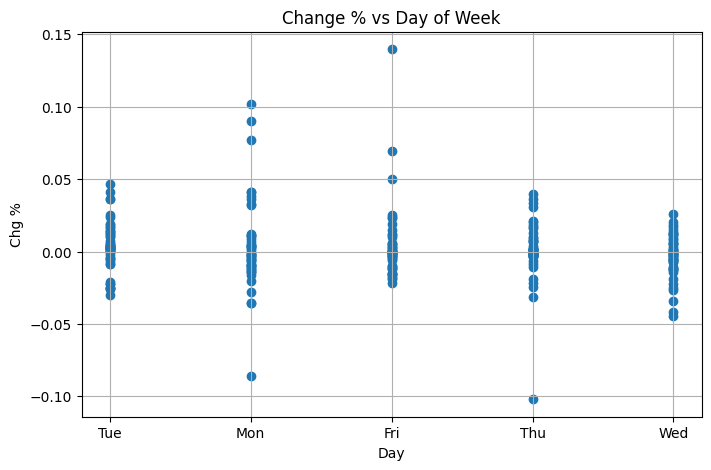

/tmp/ipykernel_476/3230977801.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe = dataframe.replace("?", np.nan)
/tmp/ipykernel_476/1037736944.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  binary_df = dataframe[binary_columns].replace({"t": 1, "f": 0})



A4 : DATA EXPLORATION

Data Types
Record ID                      int64
age                            int64
sex                           object
on thyroxine                  object
query on thyroxine            object
on antithyroid medication     object
sick                          object
pregnant                      object
thyroid surgery               object
I131 treatment                object
query hypothyroid             object
query hyperthyroid            object
lithium                       object
goitre                        object
tumor                         object
hypopituitary                 object
psych                         object
TSH measured                  object
TSH                          float64
T3 measured                   object
T3                           float64
TT4 measured                  object
TT4                          float64
T4U measured                  object
T4U                          float64
FTI measured                  object
FTI

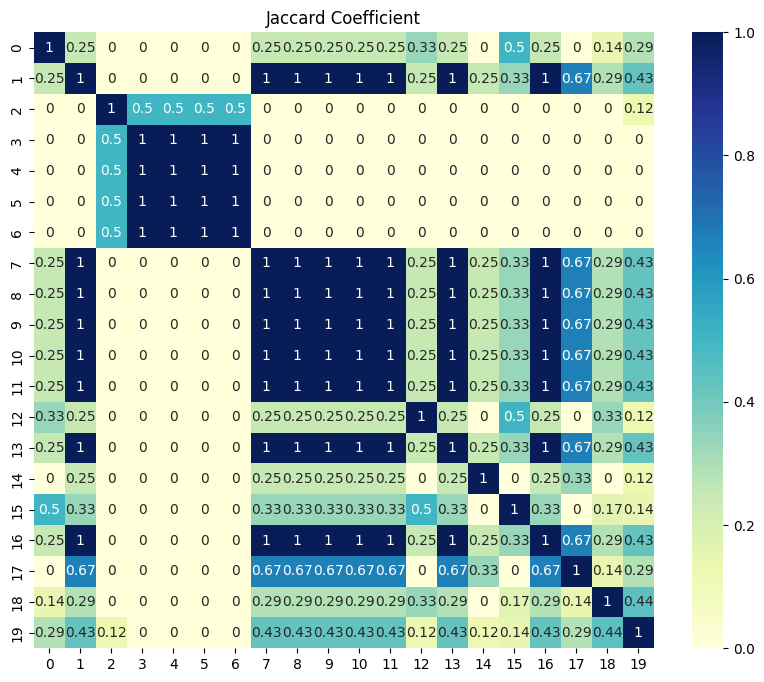

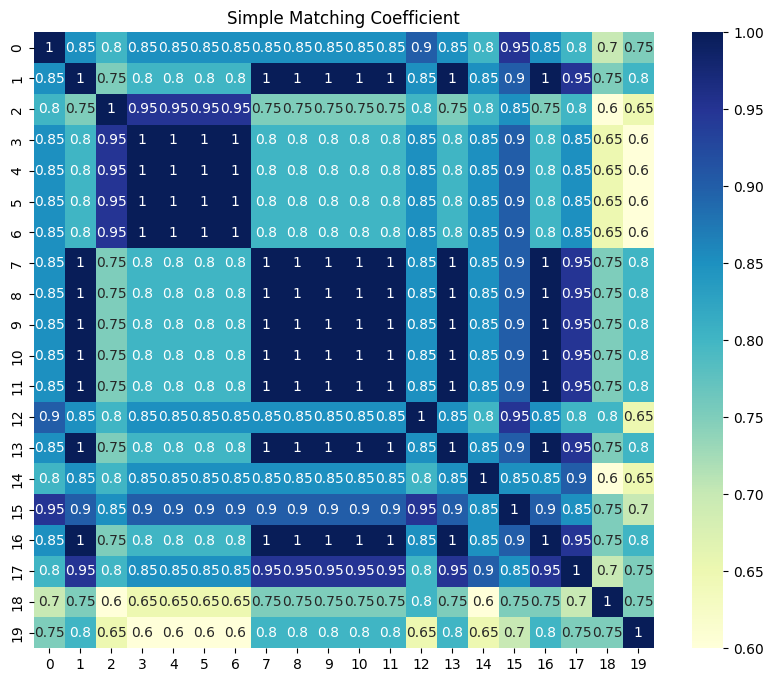

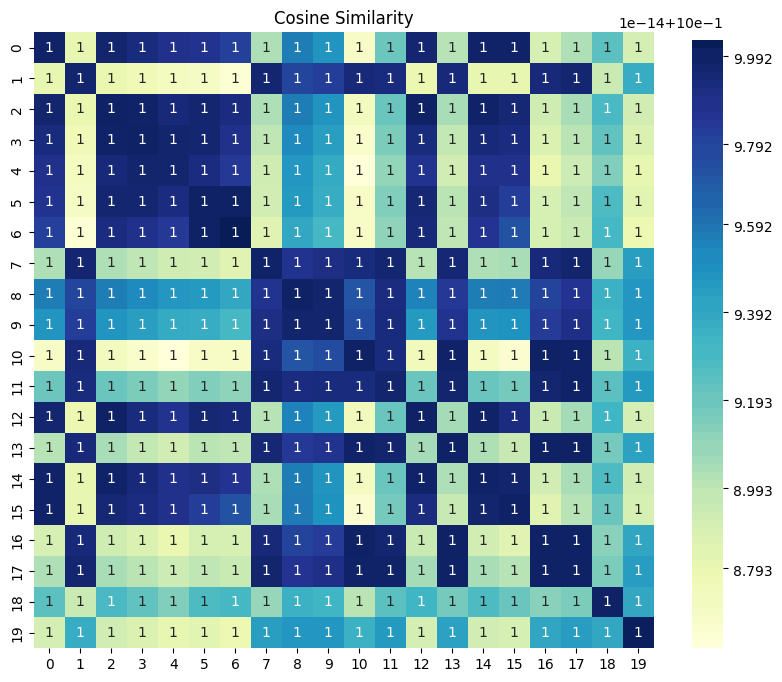


A8 : MISSING VALUE IMPUTATION

Missing Values After Imputation
Record ID                    0
age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
TBG measured                 0
TBG                          0
referral source              0
Condit

In [29]:
def main():

    purchase_df = load_sheet(DATA_FILE, "Purchase data")

    X, y = prepare_feature_output_matrix(purchase_df)

    # A1

    dimension = calculate_vector_dimension(X)
    number_of_vectors = calculate_number_of_vectors(X)
    rank = calculate_matrix_rank(X)
    product_cost = calculate_product_cost(X, y)

    print("=" * 60)
    print("A1 : PURCHASE DATA ANALYSIS")
    print("=" * 60)

    print(f"Dimension of Vector Space : {dimension}")
    print(f"Number of Observation Vectors : {number_of_vectors}")
    print(f"Rank of Feature Matrix : {rank}")

    print("\nEstimated Product Cost")
    print(f"Candies      : Rs {product_cost[0]:.2f}")
    print(f"Mangoes      : Rs {product_cost[1]:.2f}")
    print(f"Milk Packets : Rs {product_cost[2]:.2f}")

    # A2

    customer_labels = create_customer_labels(y)

    X_train, X_test, y_train, y_test = split_dataset(
        X,
        customer_labels
    )

    model = train_classifier(X_train, y_train)

    predictions = predict_labels(model, X_test)

    accuracy = calculate_accuracy(y_test, predictions)

    print("\n" + "=" * 60)
    print("A2 : CUSTOMER CLASSIFICATION")
    print("=" * 60)

    print(f"Training Samples : {len(X_train)}")
    print(f"Testing Samples  : {len(X_test)}")
    print(f"Accuracy         : {accuracy:.2%}")

    print("\nActual Labels")
    print(y_test)

    print("\nPredicted Labels")
    print(predictions)


    # A3

    stock_df = load_stock_data()

    price = stock_df["Price"].values

    mean_numpy = calculate_mean_numpy(price)
    variance_numpy = calculate_variance_numpy(price)

    mean_custom = calculate_mean(price)
    variance_custom = calculate_variance(price)

    numpy_mean_time = average_execution_time(
        calculate_mean_numpy,
        price
    )

    custom_mean_time = average_execution_time(
        calculate_mean,
        price
    )

    numpy_variance_time = average_execution_time(
        calculate_variance_numpy,
        price
    )

    custom_variance_time = average_execution_time(
        calculate_variance,
        price
    )

    wednesday_mean = calculate_mean(
        get_wednesday_prices(stock_df)
    )

    april_mean = calculate_mean(
        get_april_prices(stock_df)
    )

    probability_loss = probability_of_loss(
        stock_df["Chg%"].values
    )

    probability_profit_wednesday = probability_of_profit_on_wednesday(
        stock_df
    )

    conditional_probability = conditional_probability_profit_given_wednesday(
        stock_df
    )

    print("\n" + "=" * 60)
    print("A3 : IRCTC STOCK PRICE ANALYSIS")
    print("=" * 60)

    print(f"Population Mean                 : {mean_numpy:.4f}")
    print(f"Population Variance             : {variance_numpy:.4f}")

    print(f"\nCustom Mean                     : {mean_custom:.4f}")
    print(f"Custom Variance                 : {variance_custom:.4f}")

    print("\nAverage Execution Time (10 Runs)")

    print(f"Numpy Mean Time                 : {numpy_mean_time:.8f} sec")
    print(f"Custom Mean Time                : {custom_mean_time:.8f} sec")

    print(f"Numpy Variance Time             : {numpy_variance_time:.8f} sec")
    print(f"Custom Variance Time            : {custom_variance_time:.8f} sec")

    print(f"\nWednesday Sample Mean           : {wednesday_mean:.4f}")
    print(f"April Sample Mean               : {april_mean:.4f}")

    print(f"\nProbability of Loss             : {probability_loss:.4f}")

    print(f"Probability of Profit on Wed    : {probability_profit_wednesday:.4f}")

    print(f"Conditional Probability P(Profit|Wed) : {conditional_probability:.4f}")

    plot_change_vs_day(stock_df)


    # A4

    thyroid_df = load_thyroid_data()

    thyroid_df = preprocess_thyroid_data(thyroid_df)

    datatypes = get_attribute_datatypes(thyroid_df)

    numeric_range = get_numeric_range(thyroid_df)

    missing_values = get_missing_values(thyroid_df)

    mean_variance = get_mean_variance(thyroid_df)

    outliers = detect_outliers(thyroid_df)

    encoding = get_encoding_scheme(thyroid_df)

    print("\n" + "=" * 60)
    print("A4 : DATA EXPLORATION")
    print("=" * 60)

    print("\nData Types")
    print(datatypes)

    print("\nNumeric Range")
    print(numeric_range)

    print("\nMissing Values")
    print(missing_values)

    print("\nMean and Variance")
    print(mean_variance)

    print("\nEncoding Scheme")

    for column, method in encoding.items():
        print(f"{column} : {method}")

    print("\nOutlier Count")

    for column, count in outliers.items():
        print(f"{column} : {count}")


    # A5

    vector1, vector2 = get_binary_vectors(thyroid_df)
    f11, f10, f01, f00 = calculate_similarity_counts(
        vector1,
        vector2
    )

    jaccard = calculate_jaccard_coefficient(
        f11,
        f10,
        f01
    )

    smc = calculate_smc(
        f11,
        f10,
        f01,
        f00
    )

    print("\n" + "=" * 60)
    print("A5 : SIMILARITY MEASURE")
    print("=" * 60)

    print(f"f11 : {f11}")
    print(f"f10 : {f10}")
    print(f"f01 : {f01}")
    print(f"f00 : {f00}")

    print(f"\nJaccard Coefficient : {jaccard:.4f}")
    print(f"Simple Matching Coefficient : {smc:.4f}")


   # A6

    vector1, vector2 = prepare_vectors_for_cosine(
        thyroid_df
    )

    cosine_value = calculate_cosine_similarity(
        vector1,
        vector2
    )

    print("\n" + "=" * 60)
    print("A6 : COSINE SIMILARITY")
    print("=" * 60)

    print(f"Cosine Similarity : {cosine_value:.4f}")


    # A7

    binary_df, complete_df = get_first_twenty_vectors(
        thyroid_df
    )

    jaccard_matrix = calculate_jaccard_matrix(
        binary_df
    )

    smc_matrix = calculate_smc_matrix(
        binary_df
    )

    cosine_matrix = calculate_cosine_matrix(
        complete_df
    )

    print("\n" + "=" * 60)
    print("A7 : HEATMAP OF SIMILARITY MEASURES")
    print("=" * 60)

    plot_heatmap(
        jaccard_matrix,
        "Jaccard Coefficient"
    )

    plot_heatmap(
        smc_matrix,
        "Simple Matching Coefficient"
    )

    plot_heatmap(
        cosine_matrix,
        "Cosine Similarity"
    )


    # A8

    imputed_df = impute_missing_values(
        thyroid_df
    )

    missing_after = count_missing_values(
        imputed_df
    )

    print("\n" + "=" * 60)
    print("A8 : MISSING VALUE IMPUTATION")
    print("=" * 60)

    print("\nMissing Values After Imputation")
    print(missing_after)

main()